<a href="https://colab.research.google.com/github/PallavKhanal/MachineLearningProjects/blob/main/Titanic_Survival_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Logistic Regression

Building On What You Already Know
You just learned that linear regression finds a line through data by minimizing MSE. The output is a continuous number — a house price, a temperature, a salary.
Now the question changes. Instead of "how much?", we're asking "which one?"

Will this passenger survive? Yes or No.
Is this email spam? Yes or No.
Does this patient have cancer? Yes or No.

You might think — why not just use linear regression? Predict 1 for yes, 0 for no, pick a threshold at 0.5?
Here's why that breaks:
Imagine plotting survived (1) vs died (0) against ticket price. Linear regression draws a straight line through 0s and 1s. That line can predict 1.7 or -0.4 — neither of which is a valid probability. Worse, one extreme outlier (someone who paid $500 for a ticket) will drag the line toward them and shift everyone else's predictions.
We need something that:

Always outputs a number between 0 and 1 (a probability)
Has a meaningful decision boundary
Has a loss function that makes sense for classification

That something is logistic regression.

🔀 The Sigmoid Function — The Core Idea
Logistic regression's trick is wrapping the linear equation inside a function that squashes any number into (0, 1).
That function is the sigmoid:
σ(z) = 1 / (1 + e⁻ᶻ)
Where z is your familiar linear combination:
z = β₀ + β₁x₁ + β₂x₂ + ...
So the full model is:
P(y=1 | x) = 1 / (1 + e⁻⁽β⁰ ⁺ β¹ˣ¹ ⁺ ···⁾)
Read that as: "The probability that y equals 1, given features x."
What does the sigmoid actually do?

When z is a very large positive number → σ(z) → 1 (almost certainly class 1)
When z is a very large negative number → σ(z) → 0 (almost certainly class 0)
When z = 0 → σ(z) = 0.5 (completely uncertain)

The curve looks like a stretched S shape. It's smooth, differentiable everywhere, and always stays between 0 and 1. That's exactly what we need.
Intuitively: the linear part (z) is still doing the same job — computing a weighted sum of features. The sigmoid is just a translator that converts that raw score into a probability.

🗺️ The Decision Boundary
Once we have a probability, we need to make an actual decision: survived or died?
The default rule is simple:
if P(y=1 | x) >= 0.5 → predict class 1
if P(y=1 | x) < 0.5  → predict class 0
The decision boundary is the set of points where the model is exactly 50/50. That's where z = 0, meaning:
β₀ + β₁x₁ + β₂x₂ + ... = 0
This is a line in 2D, a plane in 3D, a hyperplane in higher dimensions. The model classifies everything on one side as class 1, everything on the other as class 0.

🎚️ Threshold Tuning
The 0.5 threshold is not sacred. It's a default that assumes both types of mistakes are equally bad.
But consider a medical test for a dangerous disease:

False Negative (you have it, model says no) → patient goes untreated → potentially fatal
False Positive (you don't have it, model says yes) → unnecessary follow-up → annoying but not deadly

These mistakes are NOT equally bad. You'd rather have more false positives than miss a real case. So you lower the threshold to 0.3 — now the model says "yes" more readily, catching more real cases at the cost of more false alarms.
This is the precision-recall tradeoff:

Lower threshold → more positives predicted → higher recall (catch more true positives), lower precision (more false alarms)
Higher threshold → fewer positives predicted → higher precision (when you say yes, you're usually right), lower recall (miss more true positives)

The ROC curve plots this tradeoff across all possible thresholds. The AUC (Area Under Curve) summarizes it in one number — 1.0 is perfect, 0.5 is random guessing.

⚖️ Class Imbalance
In the Titanic dataset, ~62% died and ~38% survived. That's imbalanced but manageable.
In real fraud detection, maybe 0.1% of transactions are fraud. A model that predicts "not fraud" for everything gets 99.9% accuracy — and is completely useless.
This happens because the model learns that ignoring the minority class minimizes loss. It takes the easy path.
class_weight='balanced' fixes this by telling sklearn to penalize mistakes on the minority class more heavily.
Internally, it computes a weight for each class:
weight_class_i = total_samples / (n_classes × samples_in_class_i)
If 38% survived, the weight for "survived" is roughly 1.32. Every mistake on a survivor counts 1.32× more than a mistake on a non-survivor during training. This forces the model to pay attention to the minority class.

📐 Core Theory: Why Log-Loss Instead of MSE?
This is one of the most important conceptual questions in ML. You already understand MSE:
MSE = (1/n) Σ (yᵢ - ŷᵢ)²
Why can't we use this for logistic regression?
Reason 1: MSE with sigmoid creates a non-convex loss.
When you plug the sigmoid into MSE, the resulting loss function has many local minima. Gradient descent can get stuck in a bad local minimum and never find the globally optimal β.
Reason 2: MSE doesn't punish confident wrong predictions harshly enough.
If the truth is y=1 and your model says P=0.001 (extremely confident it's class 0), MSE gives a loss of (1 - 0.001)² ≈ 0.998. That's a finite, not-too-alarming number.
With log-loss:
Loss = -[y·log(p) + (1-y)·log(1-p)]
If y=1 and p=0.001: loss = -log(0.001) = 6.9. That's enormous. The model is catastrophically punished for being confidently wrong.
If y=1 and p=0.999: loss = -log(0.999) ≈ 0.001. Tiny loss — this was a correct, confident prediction.
Reason 3: Log-loss is convex with logistic regression.
The combination of sigmoid + log-loss produces a perfectly bowl-shaped (convex) loss surface. Gradient descent is guaranteed to find the global minimum — no local minima.
This is not a coincidence. It's why sigmoid and log-loss were chosen together.

🔬 Deep Math: MLE Derivation of Logistic Regression
Maximum Likelihood Estimation (MLE) gives us a principled reason to use log-loss. Instead of choosing a loss function arbitrarily, we derive it from first principles.
Setup: For a binary problem, the probability of observing a label y given features x is:
P(y | x) = p^y · (1-p)^(1-y)
This is elegant. When y=1: P = p. When y=0: P = 1-p. One formula covers both cases.
Likelihood: Given n independent observations, the probability of seeing ALL of them is:
L(β) = Π P(yᵢ | xᵢ) = Π pᵢ^yᵢ · (1-pᵢ)^(1-yᵢ)
We want to find β that maximizes this — maximum likelihood.
Log-Likelihood: Products are hard to optimize. Log turns products into sums (and doesn't change where the maximum is, since log is monotonically increasing):
ℓ(β) = Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]
Maximize log-likelihood = Minimize negative log-likelihood:
-ℓ(β) = -Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]
This IS log-loss. We didn't choose log-loss because it seemed reasonable. We derived it from the statistical assumption that our labels follow a Bernoulli distribution. Log-loss is the natural, mathematically correct loss function for binary classification.

🔬 Deep Math: Gradient Descent for Logistic Regression
Taking the derivative of log-loss with respect to β:
∂(-ℓ)/∂β = (1/n) Xᵀ(p - y)
Where p is the vector of sigmoid predictions. This looks almost identical to linear regression's gradient — (predictions minus truth), projected back through the features.
The update rule:
β ← β - α · (1/n) Xᵀ(p - y)
The beautiful thing: despite the sigmoid being nonlinear, the gradient has this clean form. This is another reason sigmoid + log-loss are a matched pair — they give a gradient that's simple to compute and implement.

**MLE Derivation of Logistic Regression — Deep Dive**
Let me build this up from the ground floor, explaining the intuition behind each step, not just the mechanics.

Why MLE at All?
When we train a model, we're asking: "What parameters β make our observed data most probable?"
This is the core question of Maximum Likelihood Estimation. We're not minimizing arbitrary error — we're asking the model to tell a story that best explains what we actually saw.

Step 1: The Bernoulli Trick
The formula P(y | x) = p^y · (1-p)^(1-y) looks fancy, but it's just a clever shorthand.
Think about what we need:

When a customer churns (y=1), the probability should be p
When a customer stays (y=0), the probability should be 1-p

We could write this as an if/else. Instead, the exponent trick handles both cases in one shot:
yp^y(1-p)^(1-y)Result1p¹ = p(1-p)⁰ = 1p0p⁰ = 1(1-p)¹ = (1-p)1-p
This is just notational elegance — nothing mathematically deep yet.

Step 2: The Likelihood Function
Now imagine you have 5 customers. You observed: churned, stayed, stayed, churned, stayed → [1, 0, 0, 1, 0]
The probability of seeing this exact sequence (assuming independence) is:
L(β) = P(y₁=1) · P(y₂=0) · P(y₃=0) · P(y₄=1) · P(y₅=0)
     = p₁ · (1-p₂) · (1-p₃) · p₄ · (1-p₅)
The key insight: p isn't a fixed number — it's σ(β·x), the sigmoid of your model's weights applied to each customer's features. So when you adjust β, all the pᵢ values shift, and the likelihood changes. We want the β that makes this product as large as possible.
Why multiplication? Because independent probabilities multiply. The chance of flipping heads twice is 0.5 × 0.5 = 0.25, not 0.5 + 0.5.

Step 3: Why Log Transforms This Problem
Multiplying 1,000,000 numbers that are all between 0 and 1 is a disaster computationally. The product becomes astronomically small — computers literally round it to zero (called numerical underflow).
But there's a deeper reason. The product is hard to differentiate, and we need gradients for optimization. The log transform solves both:
log(a · b · c) = log(a) + log(b) + log(c)
The optimization is equivalent because log is strictly monotonically increasing — whatever β maximizes L(β) also maximizes log(L(β)). The peak doesn't move, you're just reshaping the landscape into something easier to work with.
So the log-likelihood becomes:
ℓ(β) = Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]
Let's sanity check one term. Suppose y=1 and your model predicts p=0.95:

Contribution: 1·log(0.95) + 0·log(0.05) = log(0.95) ≈ -0.05 (small penalty, good prediction)

Suppose y=1 but your model predicts p=0.05:

Contribution: 1·log(0.05) + 0·log(0.95) = log(0.05) ≈ -3.0 (huge penalty, terrible prediction)

The math is automatically harsh toward confident wrong predictions — not because we designed it that way, but because that's what the probability model demands.

Step 4: The Flip to a Loss Function
We want to maximize log-likelihood, but by convention optimizers minimize things. So we negate it:
Loss = -ℓ(β) = -Σ [yᵢ·log(pᵢ) + (1-yᵢ)·log(1-pᵢ)]
This is binary cross-entropy / log-loss. Identical formula, just with a minus sign. Minimizing this loss is provably identical to doing MLE under a Bernoulli assumption.

In [ ]:
# TITANIC SURVIVAL PREDICTION — LOGISTIC REGRESSION PROJECT

# Goal: predict whether a passenger survived (1) or died (0)
# based on their age, sex, class, fare, and other features.
#
# This is a BINARY CLASSIFICATION problem.
# Unlike regression where we predicted a number (house price),
# here we're predicting a category (survived / did not survive).



In [ ]:
#imports

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve
)
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading the data

# The Titanic dataset is built into seaborn — no download needed.
# It contains 891 passengers with information about who they were
# and whether they survived the sinking.

df = sns.load_dataset('titanic')
# This gives us a clean, pre-processed version of the Titanic data.
# It's the same dataset used in the famous Kaggle competition.

print(f"Shape: {df.shape}")         # (891, 15) — 891 passengers, 15 columns
print(df.head())                    # Always look at your data first
print("\nColumn names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
# Understanding your columns is step zero. Before cleaning anything,
# know what each column represents.


Shape: (891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

Column names:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

Data types:
survived          int64
pcla

Survival counts:
survived
0    549
1    342
Name: count, dtype: int64

Survival percentages:
survived
0    61.6
1    38.4
Name: proportion, dtype: float64


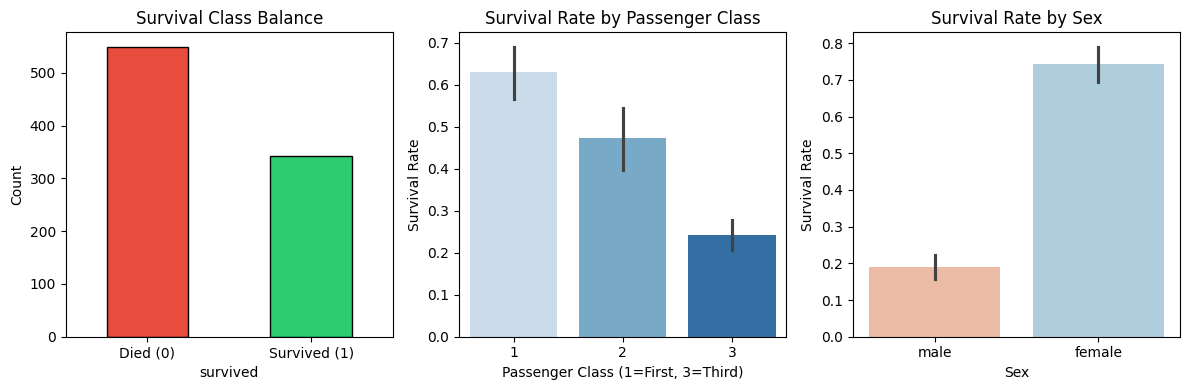

In [ ]:
#understanding the target variable - class imbalance

# In regression, we looked at the distribution of a continuous target.
# In classification, we look at the CLASS BALANCE.
#
# Why does this matter so much?
# If 95% of passengers died, a model that always predicts "died"
# gets 95% accuracy — without learning ANYTHING.
# Accuracy is a misleading metric when classes are imbalanced.
# We need to know the balance before choosing how to evaluate.

survival_counts = df['survived'].value_counts()
survival_pct = df['survived'].value_counts(normalize=True) * 100
# normalize=True gives proportions instead of counts.
# Multiply by 100 to get percentages.

print("Survival counts:")
print(survival_counts)
print("\nSurvival percentages:")
print(survival_pct.round(1))

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
survival_counts.plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.xticks([0, 1], ['Died (0)', 'Survived (1)'], rotation=0)
plt.title('Survival Class Balance')
plt.ylabel('Count')
# ~62% died, ~38% survived. Imbalanced but not extreme.
# We'll still use class_weight='balanced' as good practice.

# ── Explore survival by key features ────────────────────────
#
# Before modeling, look at which features VISUALLY separate
# the classes. If a feature separates them well in a plot,
# it'll probably be useful in the model.


plt.subplot(1, 3, 2)
sns.barplot(data=df, x='pclass', y='survived', palette='Blues')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1=First, 3=Third)')
plt.ylabel('Survival Rate')
# 1st class passengers survived at much higher rates — wealth = lifeboats


plt.subplot(1, 3, 3)
sns.barplot(data=df, x='sex', y='survived', palette='RdBu')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
# Women survived at drastically higher rates — "women and children first"

plt.tight_layout()
plt.show()

# These two plots already tell us pclass and sex will be powerful predictors.
# Data exploration guides feature selection — don't skip it.

In [ ]:
#handling the missing values

# Same principle as Ames Housing — understand WHY data is missing
# before deciding how to handle it.

print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))

# Age: 177 missing (~20%) — genuinely unknown, not "not applicable"
# Embarked: 2 missing — easy to fill with mode
# Deck: 688 missing (~77%) — too much missing to be useful, drop it

# ── Age: meaningful imputation ───────────────────────────────
#
# We can't just fill age with the overall median because age
# varied significantly by class and sex.
# A 1st class male passenger was likely older than a 3rd class child.
# Group-wise median imputation is more realistic.

df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)


# ── Embarked: fill with mode ─────────────────────────────────
#
# Only 2 missing values. Southampton (S) is by far the most common.
# Mode imputation for 2 rows out of 891 has negligible impact.

df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])


# ── Drop columns we won't use ────────────────────────────────
#
# 'deck': 77% missing — too much to impute reliably, drop it
# 'embark_town': duplicate of 'embarked' (one is a code, one is full name)
# 'who': derived from sex+age, would leak information
# 'alive': string version of 'survived' — this IS the target, never a feature
# 'alone': derived from sibsp+parch — we'll engineer this ourselves

df.drop(columns=['deck', 'embark_town', 'who', 'alive', 'alone'], inplace=True)


Missing values:
deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64


In [ ]:
#feature engineering

# Just like with houses, we can create features that capture
# domain knowledge the model can't derive from raw columns alone.

df['FamilySize'] = df['sibsp'] + df['parch'] + 1
# Total family members on board including the passenger themselves.
# sibsp = siblings/spouses, parch = parents/children.
# +1 counts the passenger themselves.
# Intuition: solo travelers and very large families had lower survival rates.
# Small families (2-4) had higher rates — enough people to help each other
# but not so many they couldn't coordinate escape.

df['IsAlone'] = (df['FamilySize'] == 1).astype(int)
# Binary flag: 1 if traveling alone, 0 if with family.
# Traveling alone was a significant risk factor.

df['FarePerPerson'] = df['fare'] / df['FamilySize']
# If a family of 4 paid £100, each person's "effective fare" is £25,
# not £100. This normalizes fare by family size for a fairer comparison.

df['AgeClass'] = df['age'] * df['pclass']
# Interaction between age and class.
# Being young AND in 1st class vs young AND in 3rd class are
# very different situations. This captures that interaction.
# Same idea as Qual_TotalSF in the housing project.

df['IsChild'] = (df['age'] < 16).astype(int)
# "Women and children first" — being a child was a survival advantage.
# This binary flag directly encodes that domain knowledge.

df['IsWoman'] = (df['sex'] == 'female').astype(int)
# We'll encode sex more formally below, but creating an explicit
# binary feature can be cleaner than relying on encoding alone.

In [ ]:
#encoding categorical variables

# Same principle as the housing project.
# Logistic regression needs numbers — convert all text to numbers.

# 'sex' has a natural binary encoding
df['sex_encoded'] = (df['sex'] == 'female').astype(int)
# 1 = female, 0 = male. Clear and interpretable.
# We could use pd.get_dummies but for binary categories,
# a single column is cleaner and avoids the dummy variable trap automatically.

# 'embarked' has no natural order — use one-hot encoding
# C = Cherbourg, Q = Queenstown, S = Southampton
embarked_dummies = pd.get_dummies(df['embarked'], prefix='embarked', drop_first=True)
# drop_first=True: with 3 categories we need only 2 columns (S is implied if C=0, Q=0)
df = pd.concat([df, embarked_dummies], axis=1)
# axis=1 means add as new COLUMNS (not new rows)

# Drop original categorical columns now that we've encoded them
df.drop(columns=['sex', 'embarked'], inplace=True)



In [ ]:
#selecting features and spliting data

# We explicitly list the features we want to use.
# This is better than just dropping columns because it forces you
# to think about each feature deliberately.
# In production, you'd document WHY each feature is included.

feature_cols = [
    'pclass',          # Passenger class — strong proxy for wealth/status
    'age',             # Age — children prioritized in evacuation
    'sibsp',           # Siblings/spouses aboard
    'parch',           # Parents/children aboard
    'fare',            # Ticket price — correlated with class and cabin location
    'sex_encoded',     # Sex — strongest single predictor
    'FamilySize',      # Total family members
    'IsAlone',         # Traveling alone flag
    'FarePerPerson',   # Normalized fare
    'AgeClass',        # Age × class interaction
    'IsChild',         # Child flag
    'IsWoman',         # Woman flag
    'embarked_Q',      # Embarked at Queenstown
    'embarked_S',      # Embarked at Southampton
]

X = df[feature_cols]
y = df['survived']     # 1 = survived, 0 = died


# ── Train/test split — with stratification ───────────────────
#
# NEW CONCEPT vs the housing project: stratify=y
#
# With imbalanced classes, a random split could accidentally put
# most survivors in training and few in test (or vice versa).
# stratify=y ensures the train and test sets have the SAME class
# proportions as the full dataset.
# Always use stratify for classification problems.

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # Preserve class proportions in both splits
)

print(f"\nTraining set: {X_train.shape[0]} passengers")
print(f"Test set:     {X_test.shape[0]} passengers")
print(f"Train survival rate: {y_train.mean():.3f}")
print(f"Test survival rate:  {y_test.mean():.3f}")
# These two rates should be nearly identical — that's stratification working.



Training set: 712 passengers
Test set:     179 passengers
Train survival rate: 0.383
Test survival rate:  0.385


In [ ]:
#scaling features

# Same reasoning as the housing project.
# 'fare' goes up to £500+, 'IsAlone' is just 0 or 1.
# Without scaling, the optimizer pays too much attention to fare.
# Fit only on training data to prevent data leakage.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#training logistic regression

# C: inverse of regularization strength (C = 1/λ).
#    IMPORTANT: This is the OPPOSITE convention from Ridge/Lasso!
#    In linear models: higher λ = more regularization
#    In LogisticRegression: higher C = LESS regularization
#    C=1.0 is sklearn's default — a moderate amount of L2 regularization.

# penalty: type of regularization ('l2' by default, also 'l1', 'elasticnet')
#    L2 (Ridge): shrinks all coefficients, keeps all features
#    L1 (Lasso): drives some to zero, automatic feature selection

# class_weight: how to handle class imbalance
#    'balanced': automatically weights minority class higher
#    None: treat all classes equally (default, bad for imbalanced data)


# solver: optimization algorithm
#    'lbfgs': good default for L2, handles multiclass
#    'liblinear': better for small datasets and L1
#    'saga': needed for ElasticNet

# max_iter: how many gradient descent steps before giving up
#    Default 100 is often not enough — 1000 is safer

log_reg = LogisticRegression(
    C=1.0,                      # Moderate regularization
    penalty='l2',               # L2 regularization (Ridge-style)
    class_weight='balanced',    # Compensate for 62/38 class imbalance
    solver='lbfgs',             # Efficient optimizer for L2
    max_iter=1000,              # Enough iterations to converge
    random_state=42
)

log_reg.fit(X_train_scaled, y_train)
# The model finds β values that maximize log-likelihood (minimize log-loss)
# on the training data, subject to the L2 regularization constraint.



LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)


Confusion Matrix:
[[90 20]
 [15 54]]


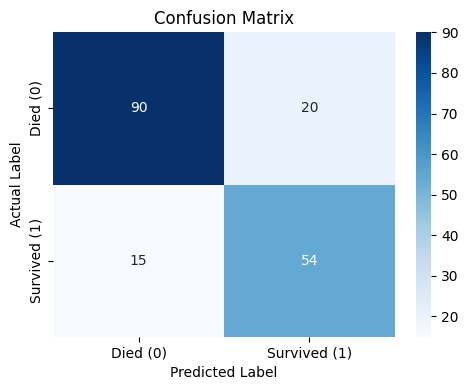


Classification Report:
              precision    recall  f1-score   support

        Died       0.86      0.82      0.84       110
    Survived       0.73      0.78      0.76        69

    accuracy                           0.80       179
   macro avg       0.79      0.80      0.80       179
weighted avg       0.81      0.80      0.81       179

Accuracy: 0.8045


In [ ]:
#evaluating - classifications metrices explained

# This is where classification diverges most from regression.
# We have multiple metrics and they measure different things.
# Understanding all of them is essential.
#
# First, let's build the CONFUSION MATRIX — the foundation of
# all classification metrics.
#
#                    Predicted: No    Predicted: Yes
# Actual: No      | True Negative  | False Positive |
# Actual: Yes     | False Negative | True Positive  |
#
# True Positive (TP):  Predicted survived, actually survived ✓
# True Negative (TN):  Predicted died, actually died ✓
# False Positive (FP): Predicted survived, actually died ✗ (Type I error)
# False Negative (FN): Predicted died, actually survived ✗ (Type II error)

y_pred = log_reg.predict(X_test_scaled)
# predict() applies the learned β, computes probabilities via sigmoid,
# then applies the 0.5 threshold to give hard 0/1 predictions.

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
# predict_proba() gives the PROBABILITY of each class.
# [:, 1] takes the second column = probability of class 1 (survived).
# This is the raw sigmoid output before the threshold is applied.
# Always save probabilities — you need them for ROC curves and threshold tuning.


# ── Confusion Matrix ─────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,             # Show numbers in cells
    fmt='d',                # Format as integers
    cmap='Blues',
    xticklabels=['Died (0)', 'Survived (1)'],
    yticklabels=['Died (0)', 'Survived (1)']
)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

# ── Classification Report ────────────────────────────────────
#
# This gives us precision, recall, and F1 for each class.
#
# PRECISION: Of all passengers predicted to survive, what % actually did?
#   Precision = TP / (TP + FP)
#   "When I say yes, how often am I right?"
#
# RECALL (Sensitivity): Of all passengers who actually survived,
#   what % did we correctly identify?
#   Recall = TP / (TP + FN)
#   "Of all actual yes cases, how many did I catch?"
#
# F1 SCORE: Harmonic mean of precision and recall.
#   F1 = 2 × (Precision × Recall) / (Precision + Recall)
#   Useful single number when you care about both.
#   Harmonic mean punishes extreme imbalance — if either precision
#   or recall is very low, F1 is also low.
#
# SUPPORT: How many actual cases of each class are in the test set.

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Died', 'Survived']))

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
# Accuracy = (TP + TN) / (TP + TN + FP + FN)
# Percentage of all predictions that were correct.
# WARNING: Always look at precision and recall alongside accuracy.
# A high accuracy with terrible recall on the minority class
# means the model is ignoring that class.



AUC-ROC Score: 0.8586


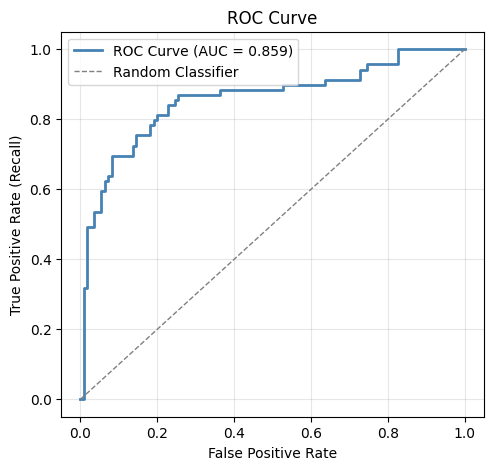

In [ ]:
#ROC curve and Area under the curve

# The ROC (Receiver Operating Characteristic) curve answers:
# "How does my model perform across ALL possible thresholds?"
#
# At each threshold, we compute:
# - True Positive Rate (Recall): TP / (TP + FN)  — what fraction of survivors do we catch?
# - False Positive Rate: FP / (FP + TN)           — what fraction of deaths do we wrongly call survivors?
#
# Plotting TPR vs FPR at every threshold gives the ROC curve.
#
# AUC (Area Under Curve):
# - AUC = 1.0: perfect model
# - AUC = 0.5: random guessing (the diagonal line)
# - AUC = 0.0: perfectly wrong (you'd flip predictions and get perfect model)
#
# AUC is threshold-independent — it measures overall discriminative ability.
# It asks: "If I randomly pick one survivor and one non-survivor,
# what's the probability my model ranks the survivor higher?

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# y_prob is the probability output — NOT the hard 0/1 predictions.
# roc_curve computes TPR and FPR at every unique probability threshold.

auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC Curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
# The diagonal gray line represents a model that guesses randomly.
# A good model's curve hugs the top-left corner.
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend()
plt.grid(alpha=0.3)

print(f"\nAUC-ROC Score: {auc:.4f}")
# AUC of 0.85+ is generally good. 0.9+ is excellent for this dataset.


Optimal threshold for F1: 0.378
Best F1 score at that threshold: 0.7643

Classification Report with Tuned Threshold:
              precision    recall  f1-score   support

        Died       0.90      0.75      0.82       110
    Survived       0.68      0.87      0.76        69

    accuracy                           0.79       179
   macro avg       0.79      0.81      0.79       179
weighted avg       0.82      0.79      0.80       179



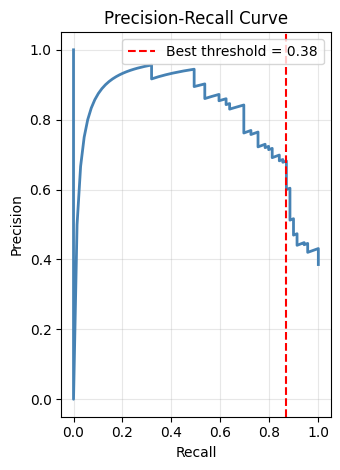

In [ ]:
#thresold tuning

# The default threshold of 0.5 is rarely optimal.
# Let's find the threshold that maximizes F1 score.
# In a real problem, you'd choose based on the business cost
# of each type of error — but F1 is a reasonable default.

precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_prob)
# Returns precision and recall at every possible threshold.
# Note: precision_recall_curve returns one more value than thresholds
# (it includes the point at threshold=0 where recall=1 by definition).

# Compute F1 at each threshold
# [:-1] trims the extra value from precision/recall to match threshold length
f1_scores = 2 * (precision_vals[:-1] * recall_vals[:-1]) / (
    precision_vals[:-1] + recall_vals[:-1] + 1e-9
)
# +1e-9 prevents division by zero if both precision and recall are 0

best_threshold_idx = np.argmax(f1_scores)           # Index of highest F1
best_threshold = pr_thresholds[best_threshold_idx]  # Corresponding threshold value
best_f1 = f1_scores[best_threshold_idx]

print(f"\nOptimal threshold for F1: {best_threshold:.3f}")
print(f"Best F1 score at that threshold: {best_f1:.4f}")

# Apply the optimal threshold to get new hard predictions
y_pred_tuned = (y_prob >= best_threshold).astype(int)
# Instead of using predict() which always uses 0.5,
# we manually threshold the probabilities.

print("\nClassification Report with Tuned Threshold:")
print(classification_report(y_test, y_pred_tuned, target_names=['Died', 'Survived']))


# Plot Precision-Recall curve
plt.subplot(1, 2, 2)
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2)
plt.axvline(recall_vals[best_threshold_idx], color='red',
            linestyle='--', label=f'Best threshold = {best_threshold:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
#cross validation - stratified k fold

# Just like with Ridge regression, we use cross-validation to
# get a more reliable performance estimate.
#
# NEW CONCEPT vs housing project: StratifiedKFold
# Regular KFold splits data randomly. With imbalanced classes,
# some folds might end up with very few minority class examples.
# StratifiedKFold ensures each fold maintains the class proportions
# of the full dataset. Always use this for classification.


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# n_splits=5: 5 folds
# shuffle=True: randomize before splitting (important for avoiding
#               any ordering bias in the data)


cv_auc = cross_val_score(
    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='roc_auc'   # AUC is better than accuracy for imbalanced problems
)

cv_f1 = cross_val_score(
    LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000),
    X_train_scaled,
    y_train,
    cv=cv,
    scoring='f1'
)

print("\n5-Fold Stratified Cross-Validation Results:")
print(f"  AUC:  {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
print(f"  F1:   {cv_f1.mean():.4f} ± {cv_f1.std():.4f}")
# The ± std tells you stability. Low std means consistent performance
# across different subsets — the model is robust, not lucky.







5-Fold Stratified Cross-Validation Results:
  AUC:  0.8536 ± 0.0255
  F1:   0.7514 ± 0.0304


In [ ]:
#tuning regularization strength

# Just like we tuned alpha (λ) for Ridge,
# we tune C for logistic regression.
# Remember: C = 1/λ, so small C = strong regularization.

C_values = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
cv_aucs = []

print("\nRegularization tuning:")
print("-" * 40)

for C in C_values:
    model = LogisticRegression(C=C, class_weight='balanced', max_iter=1000)
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_aucs.append(scores.mean())
    print(f"  C={C:<8} → AUC: {scores.mean():.4f} ± {scores.std():.4f}")

best_C = C_values[np.argmax(cv_aucs)]
print(f"\nBest C: {best_C}")


# Retrain with best C on full training set
final_model = LogisticRegression(
    C=best_C,
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)
final_model.fit(X_train_scaled, y_train)



Regularization tuning:
----------------------------------------
  C=0.001    → AUC: 0.8500 ± 0.0141
  C=0.01     → AUC: 0.8570 ± 0.0181
  C=0.1      → AUC: 0.8550 ± 0.0251
  C=1.0      → AUC: 0.8536 ± 0.0255
  C=10.0     → AUC: 0.8532 ± 0.0260
  C=100.0    → AUC: 0.8533 ± 0.0260

Best C: 0.01


LogisticRegression(C=0.01, class_weight='balanced', max_iter=1000,
                   random_state=42)

In [ ]:
#interpreting the coefficients

# Logistic regression coefficients work differently from linear regression.
# In linear regression: β = how much y changes per unit increase in x.
# In logistic regression: β = how much the LOG-ODDS change per unit increase in x.
#
# Log-odds? The odds of surviving are p/(1-p).
# The log-odds (logit) is log(p/(1-p)).
# A β of +0.5 means each unit increase in that feature
# multiplies the ODDS of survival by e^0.5 ≈ 1.65 (65% more likely).
#
# For interpretability, we exponentiate to get ODDS RATIOS.
# Odds ratio > 1: feature increases survival probability
# Odds ratio < 1: feature decreases survival probability
# Odds ratio = 1: feature has no effect

coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': final_model.coef_[0],         # [0] because coef_ is 2D for multiclass
    'OddsRatio': np.exp(final_model.coef_[0])    # e^β = multiplicative effect on odds
})
coef_df = coef_df.sort_values('Coefficient', ascending=False)

print("\nFeature Coefficients and Odds Ratios:")
print("-" * 55)
print(f"{'Feature':<20} {'Coefficient':>12} {'Odds Ratio':>12}")
print("-" * 55)
for _, row in coef_df.iterrows():
    direction = "↑ survival" if row['Coefficient'] > 0 else "↓ survival"
    print(f"{row['Feature']:<20} {row['Coefficient']:>12.4f} {row['OddsRatio']:>12.4f}  {direction}")


Feature Coefficients and Odds Ratios:
-------------------------------------------------------
Feature               Coefficient   Odds Ratio
-------------------------------------------------------
sex_encoded                0.4118       1.5095  ↑ survival
IsWoman                    0.4118       1.5095  ↑ survival
IsChild                    0.1222       1.1300  ↑ survival
fare                       0.1078       1.1139  ↑ survival
FarePerPerson              0.0917       1.0960  ↑ survival
embarked_Q                 0.0335       1.0341  ↑ survival
parch                     -0.0183       0.9819  ↓ survival
age                       -0.0453       0.9557  ↓ survival
FamilySize                -0.0969       0.9076  ↓ survival
embarked_S                -0.1068       0.8987  ↓ survival
IsAlone                   -0.1250       0.8825  ↓ survival
sibsp                     -0.1308       0.8774  ↓ survival
AgeClass                  -0.2442       0.7834  ↓ survival
pclass                    -0.2969  

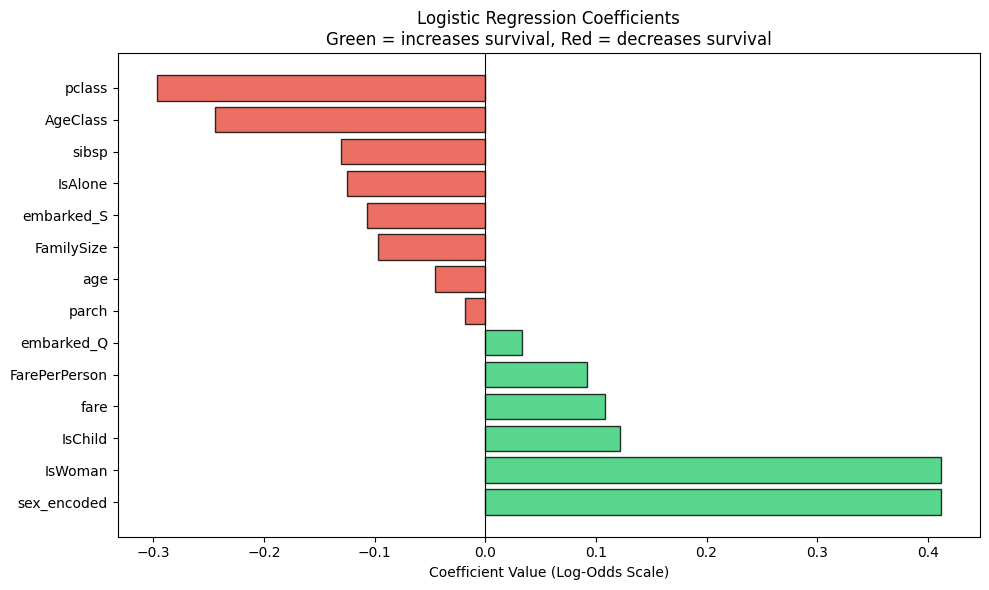

In [ ]:
#visualizing feature importance


plt.figure(figsize=(10, 6))
colors = ['#2ecc71' if c > 0 else '#e74c3c' for c in coef_df['Coefficient']]
# Green for positive (increases survival), red for negative (decreases it).
# This color coding makes the plot immediately interpretable.

plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors, edgecolor='black', alpha=0.8)
plt.axvline(0, color='black', linewidth=0.8)    # Zero line — reference for direction
plt.xlabel('Coefficient Value (Log-Odds Scale)')
plt.title('Logistic Regression Coefficients\nGreen = increases survival, Red = decreases survival')
plt.tight_layout()
plt.show()

In [ ]:
#final eval on test set

# This is the moment of truth. We evaluate ONCE on the test set
# we've kept locked away the entire time.
# If you've done everything correctly, test performance should be
# close to cross-validation performance.
# A big gap means you overfit during tuning (even with CV, if you
# try enough values you can get lucky — this is called CV overfitting).

final_probs = final_model.predict_proba(X_test_scaled)[:, 1]
final_preds = (final_probs >= best_threshold).astype(int)
# Using the optimal threshold we found in Step 11.

print("\n" + "=" * 60)
print("FINAL MODEL PERFORMANCE ON TEST SET")
print("=" * 60)
print(f"AUC-ROC:  {roc_auc_score(y_test, final_probs):.4f}")
print(f"Accuracy: {accuracy_score(y_test, final_preds):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, final_preds, target_names=['Died', 'Survived']))




FINAL MODEL PERFORMANCE ON TEST SET
AUC-ROC:  0.8423
Accuracy: 0.7430

Classification Report:
              precision    recall  f1-score   support

        Died       0.89      0.66      0.76       110
    Survived       0.62      0.87      0.72        69

    accuracy                           0.74       179
   macro avg       0.75      0.77      0.74       179
weighted avg       0.79      0.74      0.75       179

